# 📊 Thesis Flight Telemetry & Kinetic Analysis Pipeline
**Author:** Dorten  
**Context:** Master's Thesis — Autonomous Obstacle Sweep & Collision Experiments  

This notebook serves as our **dynamic, thesis-grade data science interface**. It automatically parses high-frequency ROS 2 MCAP bags, extracts OptiTrack Ground Truth tracking data, and aligns coordinate transforms. 

<details>
<summary><b>📐 Mathematical Signal Processing Rationale (Click to expand)</b></summary>


#### 1. The Finite-Difference Noise Amplification Trap
A naive numerical derivative of a discretely sampled position signal $x(t)$ is given by:
$$v_{\text{raw}}(t_i) = \frac{x(t_{i+1}) - x(t_i)}{\Delta t}$$
If our OptiTrack MoCap coordinates are measured at $100\text{ Hz}$ with a tiny spatial noise component (jitter) $e_i \sim \mathcal{N}(0, \sigma^2)$ where $\sigma \approx 1.5\text{ mm}$, the noise in the velocity estimate becomes:
$$\text{Noise}[v_{\text{raw}}] \approx \frac{\sqrt{2}\sigma}{\Delta t}$$
For $\Delta t = 0.01\text{ s}$ ($100\text{ Hz}$), the velocity noise standard deviation is scaled up by a factor of **141**, generating a massive high-frequency noise floor (approx. $\pm 0.2\text{ m/s}$ velocity spikes on a $0.4\text{ m/s}$ signal) that renders the raw derivative mathematically useless for thesis kinetic analysis.

#### 2. The Savitzky-Golay Solution
To resolve this, we employ a **Savitzky-Golay filter**. Rather than smoothing the positions and *then* taking the derivative, Savitzky-Golay performs a local least-squares polynomial fit of degree $p$ over a moving window of size $M$ (where $M$ is odd):
$$x(t) \approx a_0 + a_1 (t - t_0) + a_2 (t - t_0)^2 + \dots + a_p (t - t_0)^p$$
The analytical first derivative is then computed directly from the fitted polynomial coefficients at the center of the window:
$$v_{\text{filtered}}(t_0) = a_1$$
This preserves local dynamic features (such as sharp acceleration profiles) far better than moving averages or low-pass Butterworth filters, which tend to distort signal peaks and introduce artificial time-delays.
</details>

### 🛠️ 1. SETUP & INITIALIZATION
Configure imports, set a consistent publication-grade plot styling SSoT, and invoke the Jupyter module cache-clearing guard to ensure changes in our package are updated instantly.

In [1]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

# Resolve relative directories based on project root layout
project_root = os.path.dirname(os.path.dirname(os.path.abspath('__file__' if '__file__' in locals() else os.getcwd())))
analysis_dir = os.path.join(project_root, "dev_logs", "analysis")

if analysis_dir not in sys.path:
    sys.path.insert(0, analysis_dir)

# 🛑 SELF-HEALING RELOAD GUARD (Clears Jupyter memory cache of our custom module)
for key in list(sys.modules.keys()):
    if key.startswith('experiments_analysis') or key == 'graphics':
        del sys.modules[key]

from experiments_analysis import run, compare_all_angles

# Set elegant, professional plotting style for the thesis manuscript
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'grid.color': '#DDDDDD',
    'grid.linestyle': '--',
    'grid.linewidth': 0.7,
    'axes.grid': True
})

print("✅ Universal Modular Analysis Pipeline Active.")
print(f"📌 Project Workspace: {project_root}")

/home/dorten/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


✅ Universal Modular Analysis Pipeline Active.
📌 Project Workspace: /home/dorten/pi_drone_sshfs


### 📐 2. 90° SWEEP COLLISION EXPERIMENTS (5x Passes With vs. Without Cage)
This runs the complete analytics and visualization pipeline for the 90° collision sweep experiments.
It automatically loads all passes, prints a detailed events table, and renders top-down trajectories, velocity profiles, battery sag, and comparative boxplots.

🎬 Starting Analysis Pipeline for: 90° Column Collision (90°)
🔧 Loaded SSoT Configs: Tracker='jake_drone_frame_01', Cage D=35.8cm, Column D=9.0cm

⏳ Processing 'With Rotating Cage' passes...
✅ Successfully processed 4 passes.

⏳ Processing 'Without Cage' passes...
✅ Successfully processed 4 passes.

📈 --- Representative Pass: WITH ROTATING CAGE (flight_20260522-1638_column_sweep_loop_hardcoded) ---

📊 CHRONOLOGICAL FLIGHT EVENTS & BATTERY AUDIT JOURNAL (WITH CAGE)


Event Name,Absolute Time (s),Time Since Arming (s),Average Velocity,Battery Remaining,Voltage (V),Mocap Coordinate (ENU)
1. Log Start,0.02s,+0.02s,N/A,100.0%,24.31V,"(0.135, -0.126, 0.084)m"
3. Takeoff Detected,8.23s,+8.23s,0.087 m/s,76.1%,23.24V,"(0.336, -0.114, 0.150)m"
4. Arrived WP1,20.60s,+20.60s,0.351 m/s,59.8%,23.05V,"(-0.080, 1.082, 0.493)m"
4. Arrived WP2,21.51s,+21.51s,0.223 m/s,59.4%,22.99V,"(-0.039, 1.144, 0.520)m"
4. Arrived WP3,30.38s,+30.38s,0.711 m/s,55.0%,22.79V,"(0.130, -1.080, 0.497)m"
4. Arrived WP4,30.51s,+30.51s,1.227 m/s,54.8%,22.74V,"(0.136, -1.137, 0.490)m"
6. Log End,64.89s,+64.89s,0.462 m/s,73.6%,23.61V,"(0.223, -1.704, 0.066)m"


--------------------------------------------------------------------------------


/home/dorten/pi_drone_sshfs/dev_logs/analysis/experiments_analysis/exa_plot_trajectory.py:166: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dorten/pi_drone_sshfs/dev_logs/analysis/experiments_analysis/exa_plot_trajectory.py:170: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300)


[INFO] Trajectory plot saved successfully to: /home/dorten/pi_drone_sshfs/dev_logs/analysis/trajectory_90°_column_collision_cage.png


/home/dorten/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


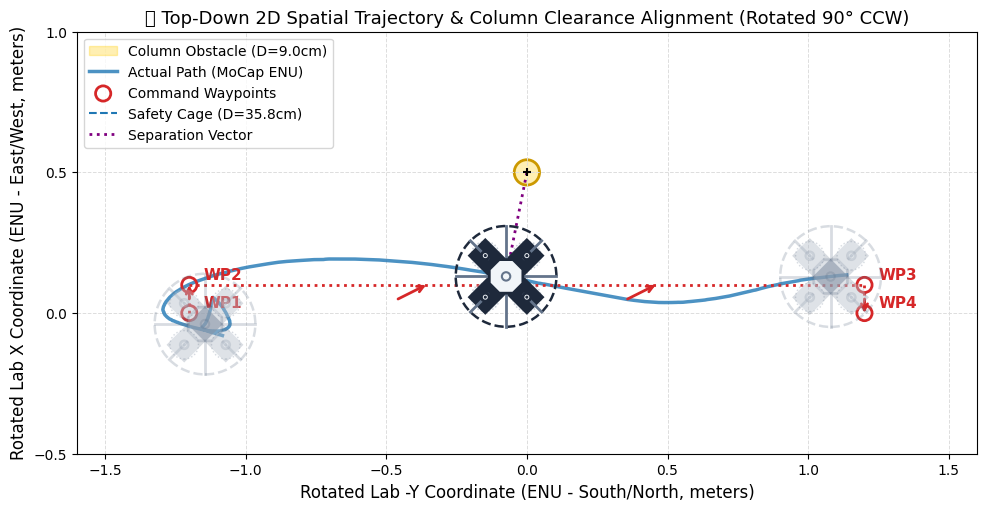

📐 Physical Separation Metrics (SSoT Configured):
   - Time of closest approach:                     t = 27.56s
   - Minimum spatial distance to column center:   0.377 m
   - Minimum physical cage clearance to surface:  15.3 cm (Cage diameter = 0.358m, Column diameter = 0.090m)


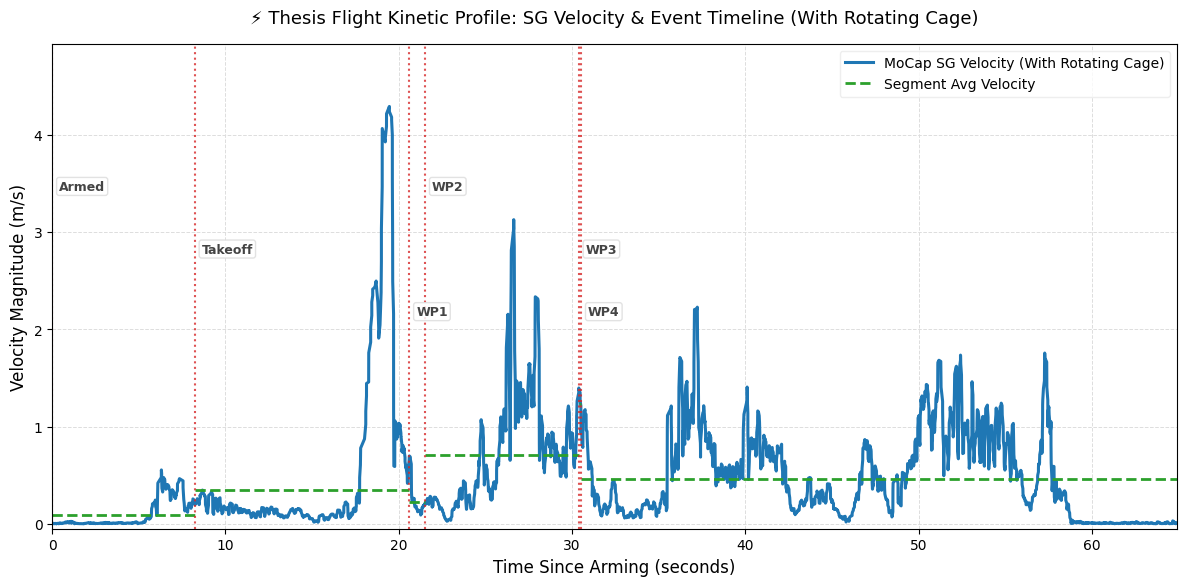

/home/dorten/pi_drone_sshfs/dev_logs/analysis/experiments_analysis/exa_plot_kinematics.py:134: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dorten/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


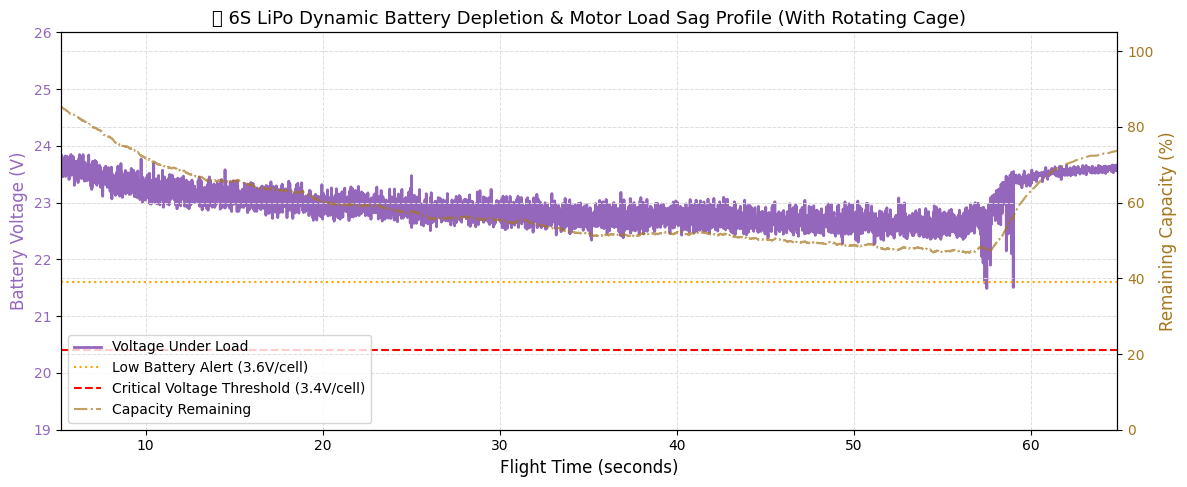

🔋 Battery Chemical Consumption Analysis (With Rotating Cage):
   - Initial Unloaded Voltage:           24.32 V
   - Minimum Voltage Sag (Takeoff/Loads): 21.49 V  (Total Drop = -2.83 V)
   - Active Flight Duration Recorded:     56.7 seconds
   - Total Capacity Consumption:          26.4%
   - Consumption Rate (load-adjusted):     27.9% capacity per minute of flight
   - Safe Flight Ceiling (40% Cutoff):    5.2 seconds


📈 --- Representative Pass: WITHOUT CAGE (flight_20260520-1926_column_sweep_loop_5cm_clearance) ---

📊 CHRONOLOGICAL FLIGHT EVENTS & BATTERY AUDIT JOURNAL (WITHOUT CAGE)


Event Name,Absolute Time (s),Time Since Arming (s),Average Velocity,Battery Remaining,Voltage (V),Mocap Coordinate (ENU)
1. Log Start,1.04s,+1.04s,N/A,38.9%,22.31V,"(0.794, 1.214, 0.102)m"
3. Takeoff Detected,8.21s,+8.21s,0.041 m/s,29.7%,21.93V,"(0.903, 1.270, 0.150)m"
6. Log End,33.72s,+33.72s,0.135 m/s,33.9%,22.56V,"(0.818, -0.993, 0.077)m"


--------------------------------------------------------------------------------
[INFO] Trajectory plot saved successfully to: /home/dorten/pi_drone_sshfs/dev_logs/analysis/trajectory_90°_column_collision_nocage.png


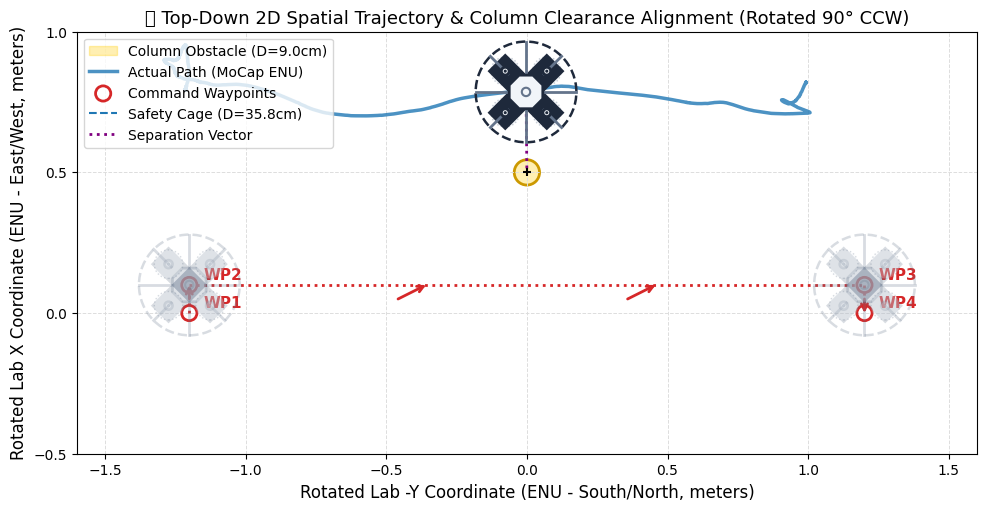

📐 Physical Separation Metrics (SSoT Configured):
   - Time of closest approach:                     t = 18.63s
   - Minimum spatial distance to column center:   0.286 m
   - Minimum physical cage clearance to surface:  6.2 cm (Cage diameter = 0.358m, Column diameter = 0.090m)


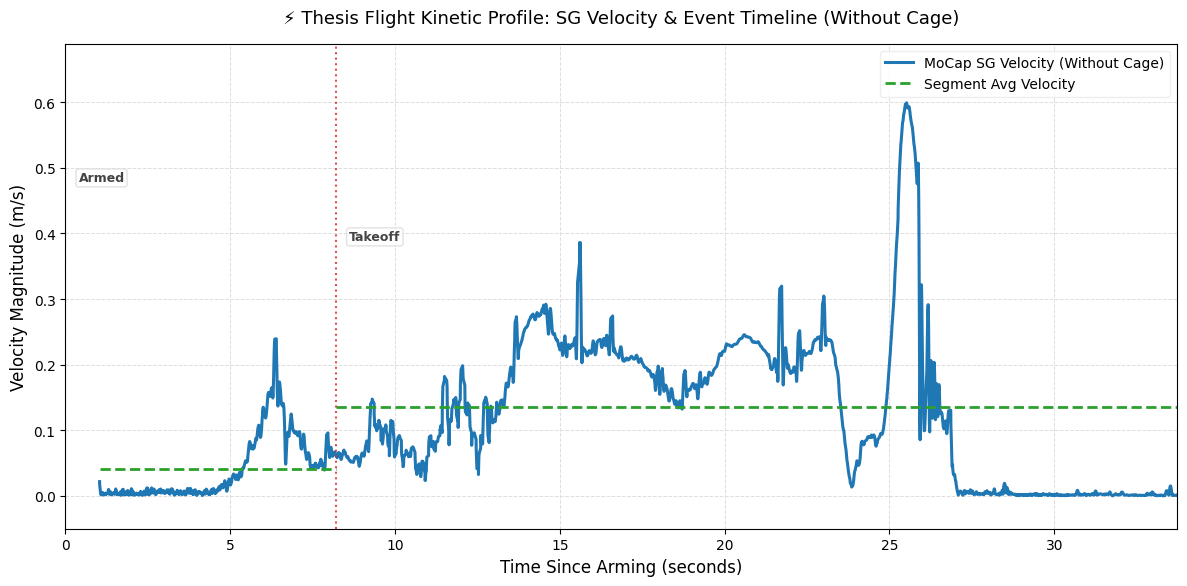

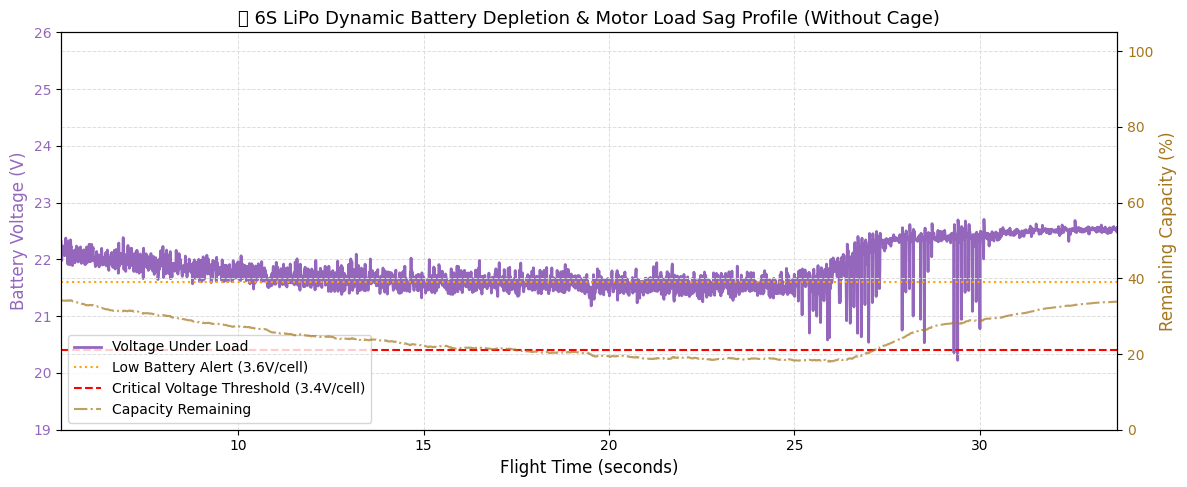

🔋 Battery Chemical Consumption Analysis (Without Cage):
   - Initial Unloaded Voltage:           22.70 V
   - Minimum Voltage Sag (Takeoff/Loads): 20.22 V  (Total Drop = -2.48 V)
   - Active Flight Duration Recorded:     25.5 seconds
   - Total Capacity Consumption:          7.2%
   - Consumption Rate (load-adjusted):     17.0% capacity per minute of flight
   - Safe Flight Ceiling (40% Cutoff):    8.5 seconds




/home/dorten/pi_drone_sshfs/dev_logs/analysis/experiments_analysis/exa_plot_statistics.py:84: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/home/dorten/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


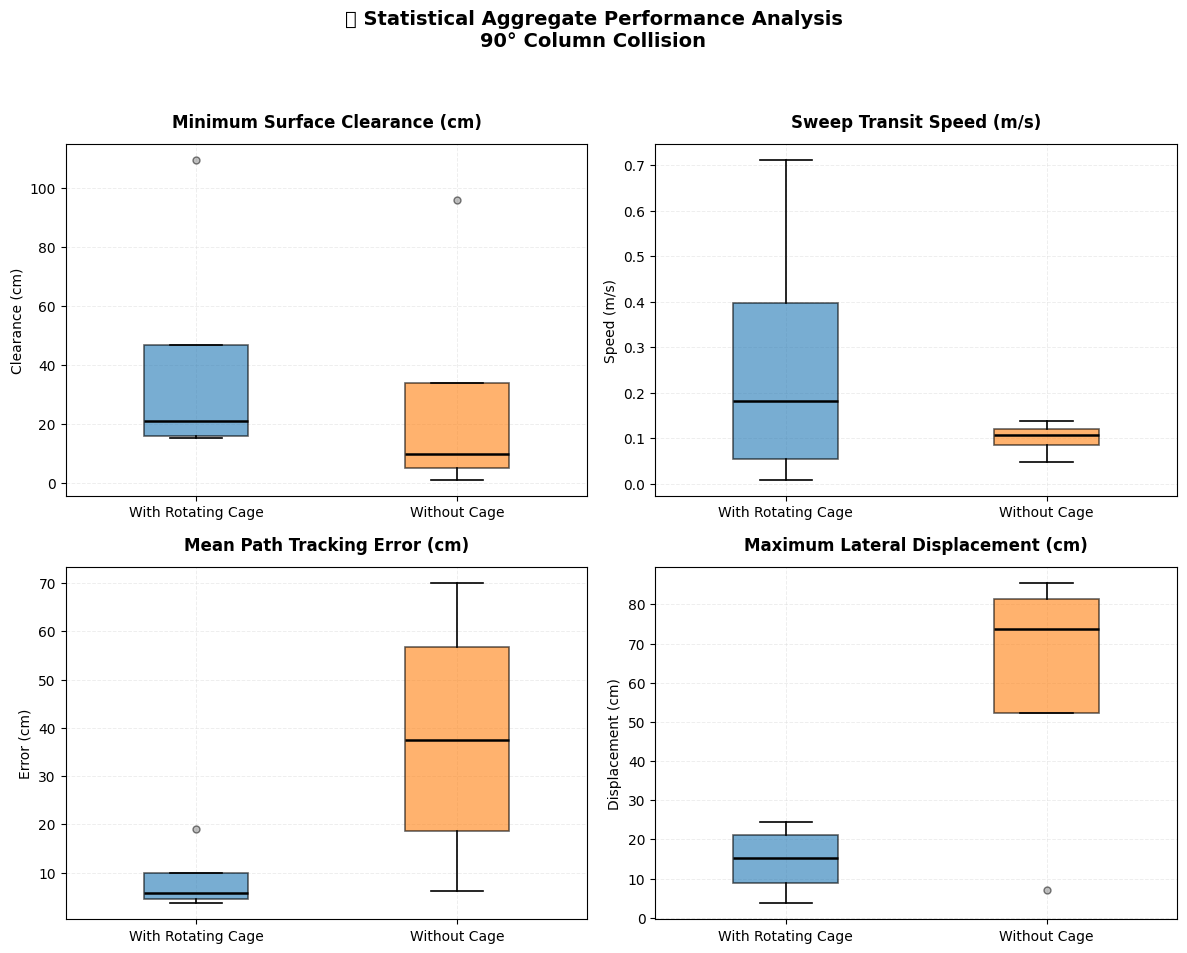

In [2]:
results_90 = run(
    label="90° Column Collision",
    angle_deg=90,
    column_x=0.500,
    column_y=0.000,
    flights_cage=[
        "flight_20260522-1638_column_sweep_loop_hardcoded",
        "flight_20260522-1637_column_sweep_loop_hardcoded",
        "flight_20260522-1531_column_sweep_loop_hardcoded",
        "flight_20260522-1517_column_sweep_loop_hardcoded"
    ],
    flights_no_cage=[
        "flight_20260520-1926_column_sweep_loop_5cm_clearance",
        "flight_20260520-1909_column_sweep_loop_5cm_clearance",
        "flight_20260520-1845_column_sweep_loop_5cm_clearance",
        "flight_20260520-1827_column_sweep_loop_5cm_clearance"
    ],
    representative_cage=0,       # Use the 1638 flight as the example
    representative_no_cage=0,
    project_root=project_root
)

### 🛸 3. FUTURE COLLISION SWEEP ANGLES TEMPLATES (75° to 0°)
You can run the same modular pipeline for other sweep angles as they are gathered. Simply add the flight directory names to the lists below and run the cell.

In [3]:
# ==============================================================================
# 75-degree Sweep Collision Experiments Template
# ==============================================================================
# results_75 = run(
#     label="75° Column Collision",
#     angle_deg=75,
#     column_x=0.500, column_y=0.000,
#     flights_cage=[
#         # Add your 5x passes with rotating cage here
#     ],
#     flights_no_cage=[
#         # Add your 5x passes without cage here
#     ],
#     representative_cage=0,
#     representative_no_cage=0,
#     project_root=project_root
# )

print("💡 Templates ready for 75°, 60°, 45°, 30°, 15°, and 0° experiments.")

💡 Templates ready for 75°, 60°, 45°, 30°, 15°, and 0° experiments.


### 📈 4. CROSS-ANGLE SCIENTIFIC METRICS TREND COMPARISON
This function takes all computed per-angle results dictionaries and compares them side-by-side. It generates clear line trend plots showing clearances, velocities, and tracking errors, which directly form the primary finding of your thesis.

/home/dorten/pi_drone_sshfs/dev_logs/analysis/experiments_analysis/exa_plot_statistics.py:157: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/home/dorten/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


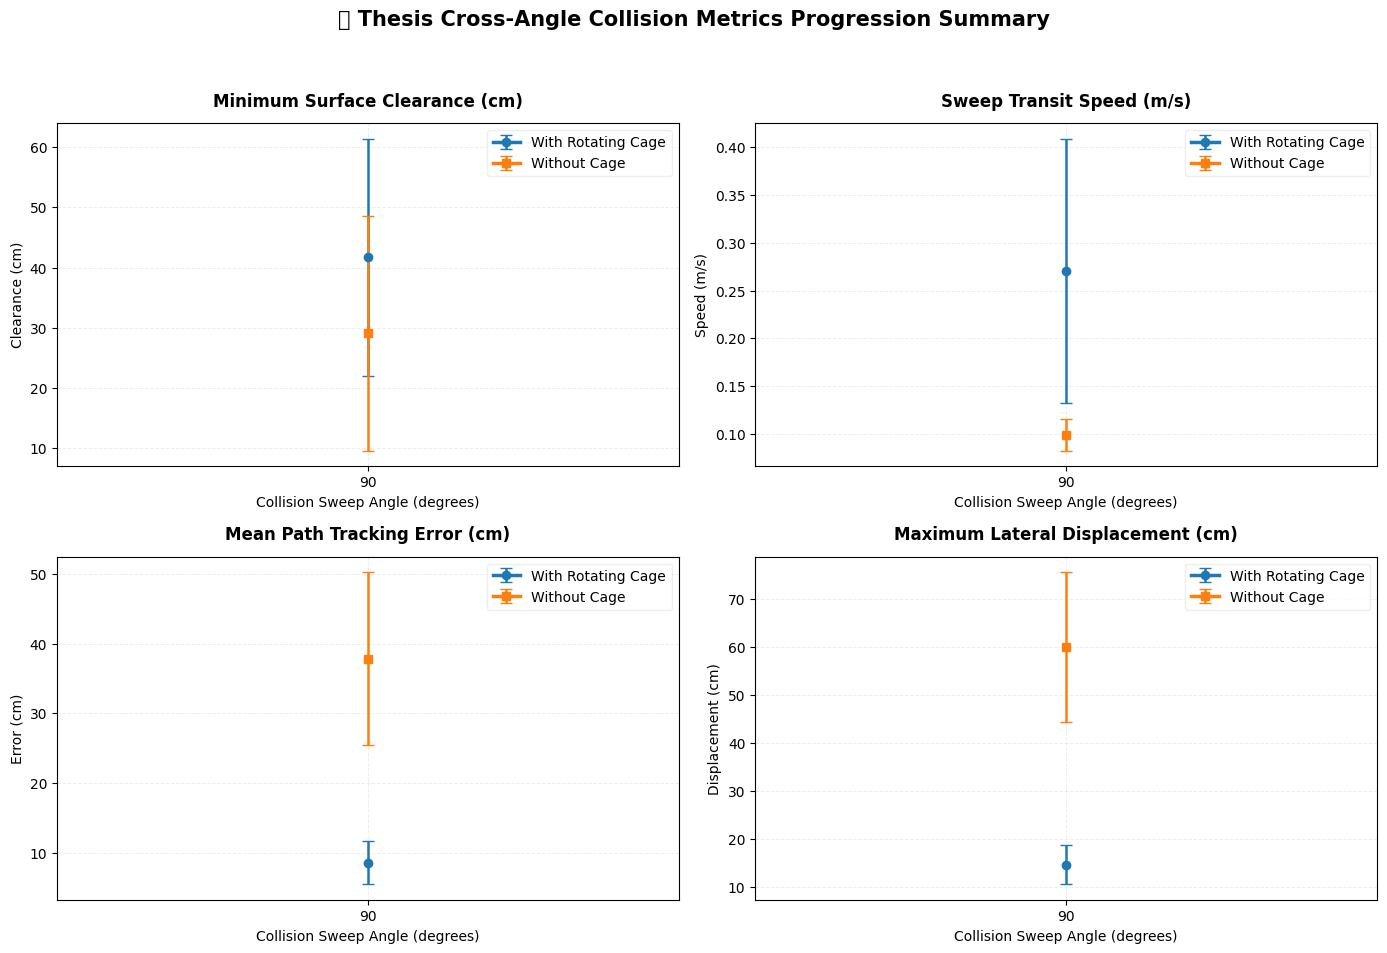

In [4]:
# Re-run statistics across all processed angles. 
# As you populate more angles, simply add their result variables to this list: 
# e.g. compare_all_angles([results_90, results_75, results_60, ...])

compare_all_angles([results_90])

### ✍️ 5. AUTOMATIC LATEX PGF/TIKZ VECTOR GRAPHICS CODE GENERATOR
Generate publication-grade TikZ code for a specific representative flight to paste directly into your Overleaf manuscript. It draws grids, waypoints, obstacles, MoCap paths, and scaled vector CAD drone representations.

In [5]:
from graphics import generate_trajectory_tikz
from experiments_analysis.exa_loader import load_drone_metadata, load_mcap, build_dataframes
from experiments_analysis.exa_kinematics import compute_velocity, find_waypoint_events, calculate_metrics

# Define which experiment and flight path you want to build the LaTeX figure for
TIKZ_FLIGHT_NAME = "flight_20260522-1638_column_sweep_loop_hardcoded"
tikz_flight_path = os.path.join(project_root, "dev_logs", "flights", TIKZ_FLIGHT_NAME)

print(f"🔮 Generating TikZ vector code for: {TIKZ_FLIGHT_NAME}")

# Load configs and data
drone_tracker_name, system_config = load_drone_metadata(project_root)
primary_body = next((b for b in system_config.get("tracked_bodies", []) if b.get("role") == "primary"), {})
obstacle_body = next((b for b in system_config.get("tracked_bodies", []) if b.get("role") == "obstacle"), {})

cage_diameter = primary_body.get("cage_diameter_m", 0.358)
column_diameter = obstacle_body.get("diameter_m", 0.09)
cage_radius = cage_diameter / 2.0
column_radius = column_diameter / 2.0

topic_data, bag_start_ns = load_mcap(tikz_flight_path)
dfs = build_dataframes(topic_data, drone_tracker_name, bag_start_ns)
df_mocap = compute_velocity(dfs['mocap'])

takeoff_mask = df_mocap['z'] > 0.15
takeoff_time = df_mocap.loc[takeoff_mask, 't'].iloc[0] if takeoff_mask.any() else dfs['arming_time'] + 2.0
wp_events = find_waypoint_events(df_mocap, takeoff_time)

metrics = calculate_metrics(df_mocap, wp_events, 0.500, 0.000, column_radius, cage_radius)

# Extract sweep segment
t_start = wp_events.get('WP1', df_mocap['t'].iloc[0])
t_end = wp_events.get('WP4', df_mocap['t'].iloc[-1])
df_mocap_sweep = df_mocap[(df_mocap['t'] >= t_start) & (df_mocap['t'] <= t_end)]

# Query positions at WP2 and WP3 transitions
def get_coords(wp_name, fallback):
    t_wp = wp_events.get(wp_name)
    if t_wp is not None:
        idx = np.searchsorted(df_mocap['t'], t_wp)
        idx = min(max(0, idx), len(df_mocap) - 1)
        return df_mocap['x'].iloc[idx], df_mocap['y'].iloc[idx]
    return fallback

wp2_x, wp2_y = get_coords('WP2', (0.1, 1.2))
wp3_x, wp3_y = get_coords('WP3', (0.1, -1.2))

# Generate and print standalone .tikz file
generate_trajectory_tikz(
    df_mocap=df_mocap_sweep,
    wps=np.array([[0.0, 1.2], [0.1, 1.2], [0.1, -1.2], [0.0, -1.2]]),
    target_flight_path=tikz_flight_path,
    flight_folder_name=TIKZ_FLIGHT_NAME,
    column_x=0.500,
    column_y=0.000,
    column_radius=column_radius,
    cage_radius=cage_radius,
    closest_t=metrics['closest_t'],
    closest_x=df_mocap.iloc[np.argmin(np.sqrt((df_mocap['x']-0.5)**2 + df_mocap['y']**2))]['x'],
    closest_y=df_mocap.iloc[np.argmin(np.sqrt((df_mocap['x']-0.5)**2 + df_mocap['y']**2))]['y'],
    closest_clearance=metrics['closest_clearance'],
    wp2_x=wp2_x,
    wp2_y=wp2_y,
    wp3_x=wp3_x,
    wp3_y=wp3_y
)

🔮 Generating TikZ vector code for: flight_20260522-1638_column_sweep_loop_hardcoded
💡 LATEX TIKZ GENERATOR ACTIVE (ROTATED 90° CCW)

This function generates standalone LaTeX TikZ vector graphics to paste directly
into your Overleaf document for professional, crisp publications.

💾 Standalone TikZ code saved successfully as: 
   /home/dorten/pi_drone_sshfs/dev_logs/flights/flight_20260522-1638_column_sweep_loop_hardcoded/flight_20260522-1638_column_sweep_loop_hardcoded_trajectory.tikz

📋 LaTeX Code Snippet:
---------------------------------------------------------------------------
% standalone TikZ vector path generated automatically from flight telemetry (Rotated 90 deg CCW)
\begin{tikzpicture}[scale=2.5]
  % Draw grid lines (limits rotated: X from -y_max to -y_min, Y from x_min to x_max)
  \draw[very thin, gray!20, step=0.5] (-1.6,-0.5) grid (1.6,1.0);

  % Draw coordinate axes
  \draw[->, thick] (-1.6,0) -- (1.6,0) node[right] {$-y$ (ENU, m)};
  \draw[->, thick] (0,-0.5) -- (0,1.0) 